---
# Instructions pour quarto
title: ""
format:
  html:
    code-fold: true
    embed-resources: true
  
---

<!-- Header stylé -->
<div style="background: linear-gradient(90deg, #4e54c8, #8f94fb); padding: 30px; border-radius: 12px; color: white; text-align: center; margin-bottom: 20px;">
  <h3 style="margin: 0; font-size: 3em;">🏠🚆Lien entre l'offre de transport et le prix du logement en Île-de-France 🏠🚆</h3>
</div>

# Introduction

L'objectif de ce projet est d'analyser comment l'accessibilité aux transports en commun influence le prix du logement en Île‑de‑France. Pour cela nous croisons deux sources complémentaires : 
- les transactions immobilières obtenues via la base de donnée DVF ("Demande de valeur foncière") pour obtenir les prix et la localisation des logements
- les données issues de l'API IDFM (Île-de-France Mobilité) décrivant les horaires prévus des transports en commun dans les 30 prochains jours.

Les traitements effectués sont les suivants :

1.Une première phase d'ingestion, nettoyage et visualisation est effectuée séparément chaque base de donnée. Ces phases son présentées dans des pages séparées : [Traitement de IDFM](idfm.html) et [Traitement de DVF](dvf.html)

2. La version nettoyée de DVF est ensuite augmentée d'informations sur la desserte en transport du logement ([Première partie](#ajout-de-la-desserte-à-DVF))

3. Des visualisations sont produites à partir de cette nouvelle base de donnée

4. [PARTIE ECONO] ???

5. Partie ML 

# Ajout de la desserte à DVF

L'approche retenue et d'ajouter au dataframe DVF des métriques indiquant la desserte en transport de chaque logement vendu.


## Calcul des arrêts les plus proches

Après avoir ouvert les fichiers intermédiares, on ajoute à chaque logement la distance à l'arrêt le plus proche pour chaque mode de transport (train, metro, tramway, bus).

Les première lignes du dataframe obtenues sont affichées pour illustrer (seules les colonnes nouvellement ajoutées sont affichées).

In [39]:
import os
import geopandas as gpd

# verifie que l'exectution se fait depuis le bon répertoire
if os.getcwd().endswith("notebooks"):
    os.chdir('..')

# ouverture des fichiers geojson
gdf_idfm_small = gpd.read_file("cache/results/passage_par_arret_synthetique.geojson")
gdf_idfm = gpd.read_file("cache/results/passage_par_arret_full.geojson")
gdf_dvf = gpd.read_file("cache/results/prix_logements.geojson")

# ajout d'une cle principale à gdf_dvf
gdf_dvf['point_id'] = gdf_dvf.index.astype(str)


# reprojeter en CRS métrique, trouver le point le plus proche et la distance en mètres
gdf_dvf_m = gdf_dvf.to_crs(epsg=3857)
gdf_idfm_small_m = gdf_idfm_small.to_crs(epsg=3857)
gdf_idfm_m = gdf_idfm.to_crs(epsg=3857)

for target in ["bus", "metro", "tramway", "train"]:
    target_df = gdf_idfm_small_m[gdf_idfm_small_m[f"nb_{target}_per_day"] > 0]

    nearest = gpd.sjoin_nearest(
        gdf_dvf_m,
        target_df[['stop_id', 'geometry']],
        how='left',
        distance_col='dist_m'
    )

    # ajouter résultats (distance en m et km, id du stop le plus proche) au GeoDataFrame original
    nearest = nearest.reset_index(drop=True)

    gdf_dvf[f"nearest_{target}_stop_id"] = nearest['stop_id']
    gdf_dvf[f"nearest_{target}_dist_m"] = nearest['dist_m']

# afficher le résultat
gdf_dvf[['adresse', 'nearest_bus_stop_id', 'nearest_bus_dist_m', 'nearest_metro_stop_id', 'nearest_metro_dist_m', 'nearest_tramway_stop_id', 'nearest_tramway_dist_m', 'nearest_train_stop_id', 'nearest_train_dist_m']].head()

,adresse,nearest_bus_stop_id,nearest_bus_dist_m,nearest_metro_stop_id,nearest_metro_dist_m,nearest_tramway_stop_id,nearest_tramway_dist_m,nearest_train_stop_id,nearest_train_dist_m
0,1 ALL ADRIENNE,IDFM:73300,155.389997,IDFM:426280,3222.044283,IDFM:73312,708.300133,IDFM:73297,810.600601
1,1 ALL ANDRE MALRAUX,IDFM:74261,264.083932,IDFM:69884,71707.338011,IDFM:68293,52890.886380,IDFM:62168,1451.228854
2,1 ALL ANDRE MALRAUX,IDFM:65153,251.057114,IDFM:71517,22369.191978,IDFM:480927,6986.766072,IDFM:73604,3325.780821
3,1 ALL ANTOINE GROSSIN,IDFM:70505,261.182603,IDFM:70671,2109.592489,IDFM:70310,2226.866100,IDFM:70505,261.182603
4,1 ALL ARAGON,IDFM:73498,154.031537,IDFM:426280,15289.094394,IDFM:73411,7031.585384,IDFM:73482,1142.816999


## Calcul de l'offre de transport dans un rayon de 1km

- **Objectif :** pour chaque point de DVF, compter et agréger l'offre de transport présente dans un rayon de 1 km.
- **Étapes :** 
    - on crée un disque de rayon 1 km autour de chaque logement.
    - on effectue une jointure spatiale pour obtenir tous les couples arrêt situés à ≤ 1 km.
    - dans chauque disque aggrège par ligne de transport (*"route"*) puis par mode (*"route_type"*) pour obtenir le nombre de passage de transport en commun par jour et par mode autour de chaque logement. L'aggrègation d'abord par ligne permet d'éviter de compter plusieurs fois un moyen de transport qui s'arrête plusieurs fois autour d'un logment.
    - après quelques étapes supplémentaires (pivot, renommage, filtrage), les résultats sont ajoutés à DVF

In [40]:
radius_m = 1000 # Distance seuil

# Créer des buffers (disques) de rayon 1 km autour de chaque point DVF
# Utilise gdf_dvf_m (déjà en CRS métrique) pour créer les buffers
gdf_dvf_buffers = gdf_dvf_m.copy()
gdf_dvf_buffers['geometry'] = gdf_dvf_m.geometry.buffer(radius_m)

# Jointure spatiale : trouver tous les couples (point DVF, arrêt de transport) où l'arrêt intersecte le buffer du point
joined = gpd.sjoin(
    gdf_dvf_buffers[['point_id', 'geometry']], 
    gdf_idfm_m[['stop_id', 'route_id', 'nb_stops_per_day', 'route_type', 'geometry']], 
    how='left',  # Jointure gauche pour garder tous les points DVF, même sans intersections
    predicate='intersects' 
).drop(columns=['index_right', 'geometry']).reset_index(drop=True) # Supprimer les colonnes inutiles après jointure


# Agrégation première : par point_id, route_id et route_type, prendre le max de nb_stops_per_day par route
# Cela évite de compter plusieurs fois une route qui passe par plusieurs arrêts dans le rayon
grouped = joined.groupby(
    ['point_id', 'route_id', 'route_type'],
    dropna=False,  # Garder les groupes avec NaN
    as_index=False
).agg(
    nb_stops_per_day_route=('nb_stops_per_day', 'max')  # Max passages par route
).reset_index(drop=True)

# Agrégation seconde : par point_id et route_type, sommer les passages, compter les routes et stations uniques
grouped2 = joined.groupby(['point_id', 'route_type'],
    dropna=False,
    as_index=False).agg(
    passage_journalier=('nb_stops_per_day', 'sum'),  # Somme des passages journaliers par mode
    nb_routes=('route_id', 'nunique'),  # Nombre de routes uniques par mode
    nb_stations=('stop_id', 'nunique')  # Nombre de stations uniques par mode
).reset_index(drop=True)

# Pivot de grouped2 pour avoir une colonne par mode de transport (route_type)
# Les valeurs sont passage_journalier, nb_routes, nb_stations pour chaque mode
grouped2_pivot = grouped2.pivot_table(
    index='point_id',
    columns='route_type', 
    values=['passage_journalier', 'nb_routes', 'nb_stations'],  
    dropna=False,  # Garder les NaN
    fill_value=0  # Remplir les valeurs manquantes par 0 (aucun passage/routes/stations)
)

# Renommer les colonnes pour mapper les codes route_type aux noms de modes
grouped2_pivot = grouped2_pivot.rename(columns={
    0: "tramway",  # 0 -> tramway
    1: "metro",   # 1 -> metro
    2: "train",   # 2 -> train
    3: "bus",     # 3 -> bus
    6: "IGNORED", # 6 -> ignoré (autres modes)
    7: "IGNORED"  # 7 -> ignoré (autres modes)
})

# Aplatir les colonnes multi-index
grouped2_pivot.columns = [
    f"{name}_{mode}_1km"  # Format : passage_journalier_tramway_1km
    for name, mode in grouped2_pivot.columns
]

# Réinitialiser l'index pour avoir point_id comme colonne
grouped2_pivot = grouped2_pivot.reset_index()

# Supprimer les colonnes contenant '_nan_' ou 'IGNORED' (modes non pertinents)
grouped2_pivot = grouped2_pivot.loc[:, ~(grouped2_pivot.columns.str.contains('_nan_') | grouped2_pivot.columns.str.contains('IGNORED'))]

# Fusionner les résultats agrégés dans gdf_dvf pour créer gdf_dvf_final
gdf_dvf_final = gdf_dvf.merge(
    grouped2_pivot,
    on='point_id',  
    how='left'
)


## Ajout de la distance au centre de Paris

On ajoute la distance au centre de Paris, cela nous permet de nous rendre compte qu'une dizaine de points sont localisés en dehors de l'Île-de-France (sans doute des erreurs de l'API de géocodage). Nous supprimons ces points.

In [41]:
# Recuperatin des coordonnees du centre de paris (station Chatelet les Halles)
# Note : on utilise les df avec les geometries en metres

centre_paris = gdf_idfm_small_m[gdf_idfm_small_m['stop_name'] == 'Châtelet les Halles']["geometry"].values[0]

# ajouter une colonne distance au centre de paris

gdf_dvf_m['geometry'] = gdf_dvf_m.geometry.to_crs(epsg=3857)
gdf_dvf_m['dist_centre_paris_m'] = gdf_dvf_m.geometry.distance(centre_paris)

# ajout au dataframe final
gdf_dvf_final = gdf_dvf_final.merge(
    gdf_dvf_m[['point_id', 'dist_centre_paris_m']],
    on='point_id',
    how='left'
)

# filtrage des points trop éloignés (hors ile de france)

print(f"Suppression de {len(gdf_dvf_final[gdf_dvf_final['dist_centre_paris_m'] > 140000])} points trop éloignés (hors ile de france) :")

gdf_dvf_final = gdf_dvf_final[gdf_dvf_final['dist_centre_paris_m'] <= 140000]

Suppression de 10 points trop éloignés (hors ile de france) :


In [42]:
# nettoyage et enregistrement du GeoDataFrame final

gdf_dvf_final.drop(['search', 'Date mutation', 'Valeur fonciere', 'result_score', 'point_id'], axis=1, inplace=True)

# ajout d'une colonne departement à gdf_dvf_final
gdf_dvf_final["Department"] = (gdf_dvf_final["Code_postal"].astype(int) // 1000).astype(str)

# reorganisation des colonnes
cols = gdf_dvf_final.columns.tolist()
cols_reordered = cols[:2] + cols[-2:]+ cols[7:8] + cols[2:7] + cols[8:-2]
gdf_dvf_final = gdf_dvf_final[cols_reordered]

print(gdf_dvf_final[gdf_dvf_final['dist_centre_paris_m'] > 100000])

                             adresse Code_postal  dist_centre_paris_m  \
135                1 ALL DES MAZURES       77880        100053.071484   
373            1 AV DE LA LIBERATION       77130        104654.586876   
419             1 AV DES MARRONNIERS       91670        101040.791056   
589                      1 BD CARNOT       77570        125749.804118   
618                   1 CHE DE FLAGY       77940        115925.598151   
...                              ...         ...                  ...   
71955         93 RUE GRANDE VARENNES       77460        123845.828031   
72232           96 LES PETITES AUNES       77690        100197.091027   
72323  97 CHE DE L'ORME DE MONFERRAT       77320        106123.319618   
72439                98 RTE DE MORET       77140        101532.700910   
72576          99 RUE DESIRE THOISON       77130        110310.801259   

      Department   Type local                Commune  Surface reelle bati  \
135           77       Maison         GREZ-SUR

## Ajout du revenu médian par commune 

Pour améliorer notre modèle de prédiction des prix du logement en Île-de-France, nous avons décidé d’**intégrer le revenu médian par commune** comme variable explicative. Cette décision découle directement de l’analyse de nos erreurs de prédiction en machine learning : nous observions systématiquement des sous-estimations à l'ouest de paris et des surestimations au nord de paris, indiquant que notre modèle ne captait pas pleinement la dimension socio-économique des communes.
Le revenu médian est une information clé : il reflète directement le pouvoir d’achat local et la capacité des ménages à acheter des logements, ce qui est naturellement lié aux prix de l’immobilier. En l’incluant, nous apportons donc au modèle un facteur structurel qui complète les données existantes sur les caractéristiques des biens et l’offre de transport.

Le téléchargement des données via pynsee peut être long nous avons donc téléchargé le dossier en local pour fluidifier le traitement. Voici le code utilisé pour l'obtenir :

In [43]:
"""
from pynsee.localdata import get_area_list, get_local_data
import pandas as pd

# Récupérer toutes les zones administratives
areas = get_area_list(update=True)

# Filtrer uniquement les communes
communes = areas[areas['AREA_TYPE'] == "Commune"]

# Filtrer les communes d'Île-de-France
# Codes régions IDF : 11
idf_coms = communes[
                    communes['CODE'].str.startswith("77") |  # Seine-et-Marne
                    communes['CODE'].str.startswith("78") |  # Yvelines
                    communes['CODE'].str.startswith("91") |  # Essonne
                    communes['CODE'].str.startswith("92") |  # Hauts-de-Seine
                    communes['CODE'].str.startswith("93") |  # Seine-Saint-Denis
                    communes['CODE'].str.startswith("94") |  # Val-de-Marne
                    communes['CODE'].str.startswith("95")]   # Val-d'Oise

# Extraire la liste des codes INSEE
idf_codes = idf_coms['CODE'].tolist()

# Ajout des arrondissements
idf_codes.extend([75001 + i for i in range(20)])
print(f"Nombre de communes en IDF : {len(idf_codes)}")
print(idf_codes[:10])
print(idf_codes[-10:])

# Récupérer les données socio-professionnelles pour toutes ces communes
idf_data = get_local_data(
    variables="INDICS_FILO_DISP",
    dataset_version="GEO2020FILO2018",
    nivgeo="COM",
    geocodes=idf_codes,
    silent=True
)

idf_data
"""


'\nfrom pynsee.localdata import get_area_list, get_local_data\nimport pandas as pd\n\n# Récupérer toutes les zones administratives\nareas = get_area_list(update=True)\n\n# Filtrer uniquement les communes\ncommunes = areas[areas[\'AREA_TYPE\'] == "Commune"]\n\n# Filtrer les communes d\'Île-de-France\n# Codes régions IDF : 11\nidf_coms = communes[\n                    communes[\'CODE\'].str.startswith("77") |  # Seine-et-Marne\n                    communes[\'CODE\'].str.startswith("78") |  # Yvelines\n                    communes[\'CODE\'].str.startswith("91") |  # Essonne\n                    communes[\'CODE\'].str.startswith("92") |  # Hauts-de-Seine\n                    communes[\'CODE\'].str.startswith("93") |  # Seine-Saint-Denis\n                    communes[\'CODE\'].str.startswith("94") |  # Val-de-Marne\n                    communes[\'CODE\'].str.startswith("95")]   # Val-d\'Oise\n\n# Extraire la liste des codes INSEE\nidf_codes = idf_coms[\'CODE\'].tolist()\n\n# Ajout des arron

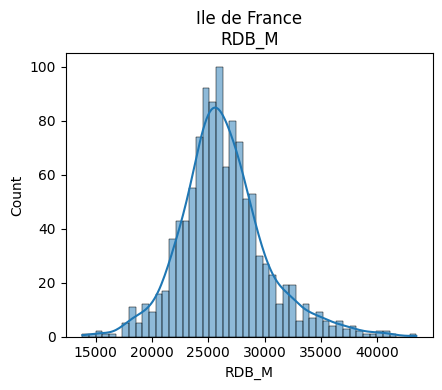

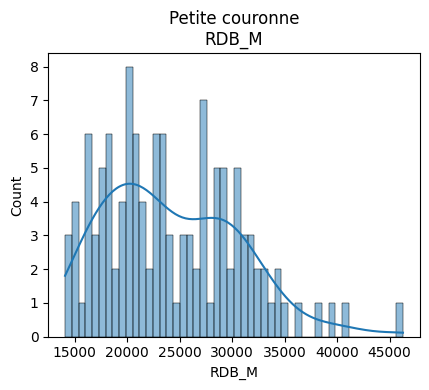

Le revenu médian par mètre carré (RDB_M) à Paris est de 28270.0 €.


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

paris = ['75']
petite_couronne = ['92','93','94']

def zone_dep(dep):
    if dep in paris:
        return 'Paris'
    elif dep in petite_couronne:
        return 'Petite couronne'
    else:
        return 'Ile de France'

path = "/home/onyxia/work/projet-python-ds/tests/idf_data2.xlsx"
df = pd.read_excel(path)
df = df[df['UNIT'] == "MEDIANE"]
df = df.rename(columns={"CODEGEO": "Code commune"})
df = df.rename(columns={"OBS_VALUE": "RDB_M"})
df['Code commune'] = df['Code commune'].astype(str)
df['Departement'] = df['Code commune'].str[:2]  
df['zone'] = df['Departement'].apply(zone_dep)

colonnes = ['RDB_M']

def plot_distributions(data, title):
    plt.figure(figsize=(16, 4))
    for i, col in enumerate(colonnes):
        plt.subplot(1, 4, i+1)
        sns.histplot(data[col], bins=50, kde=True)
        plt.title(f"{title}\n{col}")
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

IdF = df[df['zone'] == 'Ile de France']
Pc = df[df['zone'] == 'Petite couronne']

plot_distributions(IdF, "Ile de France") 
plot_distributions(Pc, "Petite couronne")

rdb_paris_value = df.loc[df['Code commune'] == '75056', 'RDB_M'].values[0]
print(f"Le revenu médian par mètre carré (RDB_M) à Paris est de {rdb_paris_value} €.")


L’analyse de la distribution du revenu médian par commune révèle une différence intéressante selon l’échelle géographique. À l’échelle de l’Île-de-France, la distribution apparaît quasi-gaussienne : la majorité des communes se situent autour d’un revenu médian moyen, tandis que les communes très riches ou très modestes sont minoritaires. En revanche, lorsqu’on se concentre sur la petite couronne, la distribution devient bimodale, avec deux pics distincts. Cela traduit l’hétérogénéité socio-économique de cette zone : certaines communes sont très aisées et résidentielles (par exemple Neuilly-sur-Seine ou Boulogne-Billancourt), tandis que d’autres présentent des revenus plus modestes (notamment certaines parties de Seine-Saint-Denis). La coexistence de ces deux types de communes crée deux groupes de revenus distincts, expliquant le caractère bimodal observé. Cette observation est utile pour interpréter les modèles de prédiction : elle montre que la variabilité locale peut être très différente de la tendance régionale globale.

In [45]:
import folium
import branca.colormap as cm
import geopandas as gpd

# Charger les communes
communes = gpd.read_file("cache/cartiflette/communes_idf.geojson")
communes['Code commune'] = communes['INSEE_COM'].astype(str)
communes = communes.merge(df[['Code commune', 'RDB_M']], on='Code commune', how='left')

# Créer la colormap
cmap = cm.LinearColormap(
    colors=['#d9d9d9', 'red'],  # blanc → bas, rouge → haut
    vmin=communes['RDB_M'].min(),
    vmax=communes['RDB_M'].max(),
    caption='Revenu médian (€)'
)

# Carte centrée sur IDF avec fond blanc
m = folium.Map(
    location=[48.85, 2.35],
    zoom_start=10,
    tiles=None  # fond blanc
)

# Ajouter les polygones avec tooltip
folium.GeoJson(
    communes,
    style_function=lambda feature: {
        'fillColor': cmap(feature['properties']['RDB_M']) if feature['properties']['RDB_M'] is not None else '#ffffff',
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['NOM', 'RDB_M'],
        aliases=['Commune', 'Revenu médian (€)'],
        localize=True
    )
).add_to(m)

# Ajouter la légende
cmap.add_to(m)

# Sauvegarder
m.save("assets/maps/revenu_median_commune.html")

L’analyse graphique des cartes révèle un lien clair entre la répartition du revenu médian et les erreurs de notre modèle. Sur la carte de l’Île-de-France, on observe que les communes où le revenu est le plus élevé coïncident souvent avec des zones où le modèle sous-estimait les prix, tandis que les communes aux revenus plus faibles correspondaient à des surestimations. Ce contraste visuel montre que le **profil spatial du revenu médian est quasiment l’inverse des erreurs de prédiction**. Intégrer cette variable dans le modèle apparaît donc particulièrement pertinent : elle fournit une information socio-économique clé qui complète les caractéristiques des biens et de l’offre de transport, et devrait permettre de corriger les biais observés, rendant les prédictions plus précises et homogènes sur le territoire.

In [46]:

gdf_dvf_final['Department'] = gdf_dvf_final['Department'].astype(str)
gdf_dvf_final['Code commune'] = gdf_dvf_final['Code commune'].astype(str)
gdf_dvf_final['Code commune'] = gdf_dvf_final['Code commune'].str.zfill(3)
gdf_dvf_final['Code commune'] = (
    gdf_dvf_final['Department'] + gdf_dvf_final['Code commune']
)
gdf_dvf_final.loc[gdf_dvf_final['Commune'] == 'PARIS', 'Code commune'] = '75056'

gdf_dvf_final['Code commune'] = gdf_dvf_final['Code commune'].astype(str)
df['Code commune'] = df['Code commune'].astype(str)

gdf_dvf_final = gdf_dvf_final.merge(
    df[['Code commune', 'RDB_M']],
    on='Code commune',
    how='left'
)

cols_to_drop = [
    'result_score_next', 'result_label', 'result_type', 'result_id', 
    'result_housenumber', 'result_name', 'result_street', 'result_postcode', 
    'result_city', 'result_context', 'result_citycode', 'result_oldcitycode', 
    'result_oldcity', 'result_district', 'result_status'
]

# Supprimer les colonnes
gdf_dvf_final = gdf_dvf_final.drop(columns=cols_to_drop, errors='ignore')

# enregistrer le GeoDataFrame final en GeoJSON
gdf_dvf_final.to_file("cache/results/logements_transport_final.geojson", driver="GeoJSON", encoding="utf-8")

gdf_dvf_final.head(5)


,adresse,Code_postal,dist_centre_paris_m,Department,Type local,Commune,Surface reelle bati,Surface terrain,Nombre pieces principales,Code commune,Valeur foncière au mètre carré,geometry,nearest_bus_stop_id,nearest_bus_dist_m,nearest_metro_stop_id,nearest_metro_dist_m,nearest_tramway_stop_id,nearest_tramway_dist_m,nearest_train_stop_id,nearest_train_dist_m,nb_routes_tramway_1km,nb_routes_metro_1km,nb_routes_train_1km,nb_routes_bus_1km,nb_stations_tramway_1km,nb_stations_metro_1km,nb_stations_train_1km,nb_stations_bus_1km,passage_journalier_tramway_1km,passage_journalier_metro_1km,passage_journalier_train_1km,passage_journalier_bus_1km,RDB_M
0,1 ALL ADRIENNE,93250,18495.327994,93,Appartement,VILLEMOMBLE,37.0,0.0,2.0,93077,4135.135135,POINT (2.50639 48.89254),IDFM:73300,155.389997,IDFM:426280,3222.044283,IDFM:73312,708.300133,IDFM:73297,810.600601,1.0,0.0,1.0,7.0,2.0,0.0,1.0,9.0,1142.0,0.0,164.0,1806.0,22880.0
1,1 ALL ANDRE MALRAUX,77370,91147.159895,77,Maison,NANGIS,81.0,232.0,4.0,77327,2888.888889,POINT (3.02135 48.55532),IDFM:74261,264.083932,IDFM:69884,71707.338011,IDFM:68293,52890.886380,IDFM:62168,1451.228854,0.0,0.0,0.0,14.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,280.0,18930.0
2,1 ALL ANDRE MALRAUX,78260,35301.849789,78,Maison,ACHERES,88.0,408.0,4.0,78005,3784.090909,POINT (2.06194 48.9531),IDFM:65153,251.057114,IDFM:71517,22369.191978,IDFM:480927,6986.766072,IDFM:73604,3325.780821,0.0,0.0,0.0,8.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,2305.0,21970.0
3,1 ALL ANTOINE GROSSIN,92140,11748.500396,92,Maison,CLAMART,95.0,0.0,4.0,92023,7476.315789,POINT (2.27316 48.8121),IDFM:70505,261.182603,IDFM:70671,2109.592489,IDFM:70310,2226.866100,IDFM:70505,261.182603,0.0,0.0,1.0,12.0,0.0,0.0,1.0,11.0,0.0,0.0,172.0,2901.0,27580.0
4,1 ALL ARAGON,93290,29249.801463,93,Appartement,TREMBLAY-EN-FRANCE,63.0,0.0,4.0,93073,2523.809524,POINT (2.57231 48.95058),IDFM:73498,154.031537,IDFM:426280,15289.094394,IDFM:73411,7031.585384,IDFM:73482,1142.816999,0.0,0.0,0.0,8.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,1938.0,20710.0


## Visualisation du résultat

Pour illustre les données obtenues, on affiche le premier point de DVF. La carte interactive montre :
- Un marqueur bleu pour le point DVF.
- Des marqueurs rouges pour les arrêts de transport à moins de 1 km (avec passages journaliers agrégés par mode).
- Des marqueurs verts pour les arrêts les plus proches par mode de transport (bus, métro, tramway, train), avec distances en mètres.

In [47]:
from branca.element import Template, MacroElement
from script.leaflet_tools import FondCarteLeaflet
import folium
import great_tables as gt


# affichage des stops within radius on a map for the first point only
df = joined

m = FondCarteLeaflet(afficher_grande_couronne=True).get_map()

first_point = gdf_dvf.iloc[0]
folium.CircleMarker(
    location=[first_point.geometry.y, first_point.geometry.x],
    popup=first_point['point_id'],
    color='blue'
).add_to(m)
for _, row in df[df['point_id'] == first_point['point_id']].iterrows():
    stop = gdf_idfm_small[gdf_idfm_small['stop_id'] == row['stop_id']]

    stop0 = stop.iloc[0]
    route_name = stop0.get('stop_name', None)

    folium.Marker(
        location=[stop0.geometry.y, stop0.geometry.x],
        tooltip=f"Nearby stop:\n{route_name}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m)

m

for target in ["bus", "metro", "tramway", "train"]:
    stop_id = first_point.get(f"nearest_{target}_stop_id")
    stop = gdf_idfm_small[gdf_idfm_small['stop_id'] == stop_id]

    stop0 = stop.iloc[0]
    route_name = stop0.get('stop_name', None)

    folium.Marker(
        location=[stop0.geometry.y, stop0.geometry.x],
        tooltip=f"Nearest {target} stop:\n{route_name}",
        icon=folium.Icon(color='green', icon='info-sign')
    ).add_to(m)

# add legend once (do not recreate inside the loop)
legend_html = """
{% macro html(this, kwargs) %}
<div style="position: fixed; 
    bottom: 50px; left: 50px; width: 220px; padding:8px;
    border:2px solid grey; z-index:9999; font-size:14px;
    background-color:white; box-shadow:2px 2px 6px rgba(0,0,0,0.15);
    ">
  <b>Legend</b><br>
  <span style="display:inline-block;width:12px;height:12px;background:blue;border-radius:50%;margin-right:8px;vertical-align:middle;"></span>
    Point (DVF sample)<br>
  <span style="display:inline-block;width:12px;height:12px;background:red;border-radius:3px;margin-right:8px;vertical-align:middle;"></span>
    Nearby stop (within radius)<br>
  <span style="display:inline-block;width:12px;height:12px;background:green;border-radius:3px;margin-right:8px;vertical-align:middle;"></span>
    Nearest stop (by mode)<br>
  <hr style="margin:6px 0"/>
  <small>Hover or click markers for details</small>
</div>
{% endmacro %}
"""
legend = MacroElement()
legend._template = Template(legend_html)
m.get_root().add_child(legend)


# Sauvegarde de la carte 
from pathlib import Path

assets = Path("assets/maps")
assets.mkdir(parents=True, exist_ok=True)

m.save(assets / "main1.html")

[![Interactive map](/assets/maps/main1.png)](/assets/maps/main1.html)

In [48]:
from great_tables import GT
import numpy as np
import pandas as pd

# rebuild the transposed single-row table with groups


gdf_dvf_final_filtred = gdf_dvf_final.drop(columns=['nearest_tramway_stop_id', 'nearest_train_stop_id', 'nearest_bus_stop_id', 'nearest_metro_stop_id'])

groups = ["Localisation"] * 6 + ["Caractéristiques du logement"] * 5 + ["Distances des transports"] * 4 + ["Transports dans un rayon de 1km"] * (len(gdf_dvf_final_filtred.columns) - 15)

# compute stats for each column
rows = []
for col in gdf_dvf_final_filtred.columns:

    if pd.api.types.is_numeric_dtype(gdf_dvf_final_filtred[col]):
        min_s = f"{gdf_dvf_final_filtred[col].min():,.1f}"
        max_s = f"{gdf_dvf_final_filtred[col].max():,.1f}"
        mean_s = f"{gdf_dvf_final_filtred[col].mean():,.1f}"
        quartile_25 = f"{gdf_dvf_final_filtred[col].quantile(0.25):,.1f}"
        median = f"{gdf_dvf_final_filtred[col].median():,.1f}"
        quartile_75 = f"{gdf_dvf_final_filtred[col].quantile(0.75):,.1f}"
    else:
        try:
            min_s = str(gdf_dvf_final_filtred[col].min())
            max_s = str(gdf_dvf_final_filtred[col].max())
            # crop long strings for display
            if len(min_s) > 7:
                min_s = min_s[:4] + "..."
            if len(max_s) > 7:
                max_s = max_s[:4] + "..."
        except Exception:
            min_s = max_s = "-"
        mean_s = "-"
        cv_s = "-"
        quartile_25 = "-"
        median = "-"
        quartile_75 = "-"

    rows.append({"index": col, "Moyenne": mean_s, "Min": min_s, "25%": quartile_25, "50%": median, "75%": quartile_75, "Max": max_s,})

df_stats = pd.DataFrame(rows).assign(group=groups)

(
    GT(df_stats)
    .tab_stub(rowname_col="index", groupname_col="group")
    .tab_header("Statistiques descriptives des colonnes du jeu de données")
)

GT(_tbl_data=                             index   Moyenne       Min       25%       50%  \
0                          adresse         -   1 AL...         -         -   
1                      Code_postal         -     75001         -         -   
2              dist_centre_paris_m  26,701.4     137.3   8,721.2  19,903.2   
3                       Department         -        75         -         -   
4                       Type local         -   Appa...         -         -   
5                          Commune         -   ABLE...         -         -   
6              Surface reelle bati      72.8       9.0      40.0      65.0   
7                  Surface terrain     199.6       0.0       0.0       0.0   
8        Nombre pieces principales       3.3       1.0       2.0       3.0   
9                     Code commune         -     75012         -         -   
10  Valeur foncière au mètre carré   5,539.3   1,000.0   3,104.9   4,488.9   
11                        geometry         -         -         -         -   
12              nearest_bus_dist_m     251.8       0.3     145.4     221.0   
13            nearest_metro_dist_m  14,760.6       8.2     633.2   6,343.8   
14          nearest_tramway_dist_m   9,542.4      10.6   1,671.6   3,995.7   
15            nearest_train_dist_m   2,152.7      10.6     935.9   1,543.5   
16           nb_routes_tramway_1km       0.1       0.0       0.0       0.0   
17             nb_routes_metro_1km       0.7       0.0       0.0       0.0   
18             nb_routes_train_1km       0.4       0.0       0.0       0.0   
19               nb_routes_bus_1km       9.3       0.0       5.0       8.0   
20         nb_stations_tramway_1km       0.2       0.0       0.0       0.0   
21           nb_stations_metro_1km       1.1       0.0       0.0       0.0   
22           nb_stations_train_1km       0.3       0.0       0.0       0.0   
23             nb_stations_bus_1km       9.5       0.0       6.0       9.0   
24  passage_journalier_tramway_1km     103.1       0.0       0.0       0.0   
25    passage_journalier_metro_1km   1,069.4       0.0       0.0       0.0   
26    passage_journalier_train_1km     100.9       0.0       0.0       0.0   
27      passage_journalier_bus_1km   2,979.0       0.0     858.5   2,282.0   
28                           RDB_M  25,593.2  13,810.0  22,060.0  26,240.0   

         75%        Max                            group  
0          -    990 ...                     Localisation  
1          -      95880                     Localisation  
2   37,965.4  138,652.3                     Localisation  
3          -         95                     Localisation  
4          -     Maison                     Localisation  
5          -     YERRES                     Localisation  
6       91.0      300.0     Caractéristiques du logement  
7      262.0    9,940.0     Caractéristiques du logement  
8        4.0       20.0     Caractéristiques du logement  
9          -      95690     Caractéristiques du logement  
10   7,544.5   20,000.0     Caractéristiques du logement  
11         -          -         Distances des transports  
12     313.7    4,261.1         Distances des transports  
13  22,281.8  119,312.3         Distances des transports  
14  11,764.0   92,561.1         Distances des transports  
15   2,453.8   35,427.2  Transports dans un rayon de 1km  
16       0.0        3.0  Transports dans un rayon de 1km  
17       1.0        8.0  Transports dans un rayon de 1km  
18       1.0        9.0  Transports dans un rayon de 1km  
19      12.0       48.0  Transports dans un rayon de 1km  
20       0.0        6.0  Transports dans un rayon de 1km  
21       1.0       11.0  Transports dans un rayon de 1km  
22       1.0        3.0  Transports dans un rayon de 1km  
23      13.0       27.0  Transports dans un rayon de 1km  
24       0.0    3,329.0  Transports dans un rayon de 1km  
25     920.0   14,720.0  Transports dans un rayon de 1km  
26      87.0    2,506.0  Transports dans un rayon de 

In [49]:


# import geopandas as gpd

# import folium
# import branca.colormap as cm
# from numpy import log

# import os
# if os.getcwd().endswith("notebooks"):
#     os.chdir('..')
    
# from script.leaflet_tools import FondCarteLeaflet

# m = FondCarteLeaflet(afficher_grande_couronne=True).get_map()
# idf = gpd.read_file("cache/results/prix_logements.geojson")


# for _, row in gdf_dvf_final[gdf_dvf_final['dist_centre_paris_m'] > 140000].iterrows():
#     folium.CircleMarker(
#         location=[row.geometry.y, row.geometry.x], 
#         radius=0.5,
#         tooltip=f"{row['Valeur foncière au mètre carré']:.0f} €/m²",
#         color="blue",
#         fill=True,
#         fill_color="blue",
#         fill_opacity=0.7
#     ).add_to(m)
# # m



# Machine Learning pour la prédiction du prix des logements

Nous avons choisi de mettre en place un **modèle de Machine Learning** pour prédire le prix des logements. L’intérêt de cette approche est multiple :

1. **Automatiser l’analyse de grandes quantités de données** : un agent immobilier ou un analyste peut traiter des milliers de biens et de caractéristiques sans calcul manuel fastidieux.
2. **Identifier les facteurs importants** : le modèle peut montrer quels éléments (surface, nombre de pièces, proximité des transports, revenu médian de la commune…) influencent le plus le prix.
3. **Prédictions plus fines que la moyenne par quartier** : contrairement à une simple estimation moyenne, le modèle prend en compte les caractéristiques spécifiques du logement et de son environnement.
4. **Applications concrètes** :
   - Donner une fourchette de prix indicative pour un bien.
   - Comparer rapidement les quartiers ou types de logement.
   - Aider à détecter les biens surévalués ou sous-évalués.

Pour ce projet, nous utilisons **Random Forest**, un algorithme robuste qui combine plusieurs arbres de décision pour améliorer la précision des prédictions tout en limitant le risque de surapprentissage.


In [50]:
import geopandas as gpd
import pandas as pd
import os
if os.getcwd().endswith("notebooks"):
    os.chdir('..')

# Load a sample geospatial dataset
gdf = gpd.read_file("cache/results/logements_transport_final.geojson")

# Display the first few rows of the GeoDataFrame
# ensure every column is shown
pd.set_option('display.max_columns', None)
print(gdf.keys())

gdf = gdf.drop(columns=["adresse", "Commune", "Code commune",
                        "nearest_bus_stop_id", "nearest_metro_stop_id",
                        "nearest_train_stop_id", "nearest_tramway_stop_id"])
save_gdf = gdf.copy()

Index(['adresse', 'Code_postal', 'dist_centre_paris_m', 'Department',
       'Type local', 'Commune', 'Surface reelle bati', 'Surface terrain',
       'Nombre pieces principales', 'Code commune',
       'Valeur foncière au mètre carré', 'nearest_bus_stop_id',
       'nearest_bus_dist_m', 'nearest_metro_stop_id', 'nearest_metro_dist_m',
       'nearest_tramway_stop_id', 'nearest_tramway_dist_m',
       'nearest_train_stop_id', 'nearest_train_dist_m',
       'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km',
       'nb_routes_bus_1km', 'nb_stations_tramway_1km', 'nb_stations_metro_1km',
       'nb_stations_train_1km', 'nb_stations_bus_1km',
       'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
       'passage_journalier_train_1km', 'passage_journalier_bus_1km', 'RDB_M',
       'geometry'],
      dtype='object')


In [51]:
gdf = save_gdf.copy()

print(gdf["Department"].value_counts())

# 3 dataframes pour Paris, Petite Couronne, Grande Couronne
paris = gdf[gdf["Department"] == "75"].drop(columns=["Department"])
pc = gdf[gdf["Department"].isin(["92", "93", "94"])].drop(columns=["Department"])
gc = gdf[gdf["Department"].isin(["77", "78", "91", "95"])].drop(columns=["Department"])

Department
75    16443
77     9455
92     9151
78     8220
91     7762
93     7345
95     7204
94     7023
Name: count, dtype: int64


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, accuracy_score


def RF_model(gdf, categorical_cols, numeric_cols, target_col="Valeur foncière au mètre carré", random_state = 42, test_size=0.2, use_classifier=False):

    # filtrage des colonnes utiles
    df = gdf.copy()

    # retirer lignes sans target
    df = df[~df[target_col].isna()].reset_index(drop=True)

    features = categorical_cols + numeric_cols

    # pipeline de preprocessing
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ], remainder="drop")

    model = RandomForestRegressor(random_state=random_state, n_estimators=150, max_depth=15, min_samples_split=5, n_jobs=1)
    if use_classifier:
        model = RandomForestClassifier(random_state=random_state, n_estimators=150, max_depth=15, min_samples_split=5, n_jobs=1)            

    # pipeline complet avec Lasso alpha permet de faire de la sélection de variables
    pipe = Pipeline([
        ("preproc", preprocessor),
        ("model", model),
    ])

    # train/test split
    X = df[features]
    y = df[target_col].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # entraînement
    pipe.fit(X_train, y_train)

    # évaluation
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"R² train: {train_score:.4f}")
    print(f"R² test: {test_score:.4f}")

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    result = {"R²_train": train_score, "R²_test": test_score}
    if not use_classifier:
        result["MSE_train"] = mean_squared_error(y_train, y_train_pred)
        result["MSE_test"] = mean_squared_error(y_test, y_test_pred)
        # print(f"MSE train: {result["MSE_train"] :.4f}")
        # print(f"MSE test: {result["MSE_test"] :.4f}")
    else:
        result["Accuracy_train"] = accuracy_score(y_train, y_train_pred)
        result["Accuracy_test"] = accuracy_score(y_test, y_test_pred)
        # print(f"Accuracy train: {result["Accuracy_train"] :.4f}")
        # print(f"Accuracy test: {result["Accuracy_test"] :.4f}")

    y_pred = pipe.predict(X)
    return y_pred, result



In [53]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Définition des colonnes
categorical_cols = [
    "Type local",
]
numeric_cols = [
    "Surface reelle bati",
    "Surface terrain",
    "Nombre pieces principales",
]

numeric_cols_transport = [
    "nearest_bus_dist_m",
    "nearest_metro_dist_m",
    "nearest_tramway_dist_m",
    "nearest_train_dist_m",
    "nb_routes_tramway_1km",
    "nb_routes_metro_1km",
    "nb_routes_train_1km",
    "nb_routes_bus_1km",
    "nb_stations_tramway_1km",
    "nb_stations_metro_1km",
    "nb_stations_train_1km",
    "nb_stations_bus_1km",
    "passage_journalier_tramway_1km",
    "passage_journalier_metro_1km",
    "passage_journalier_train_1km",
    "passage_journalier_bus_1km",
]

revenu = ["RDB_M"]

# Liste pour stocker les résultats
list_of_results = []

model_metadata = [
    {
        "short_name": "prix_on_logement",
        "long_name": "Caractéristiques du bien",
        "cat": categorical_cols,
        "num": numeric_cols,
        "target": "Valeur foncière au mètre carré",
        "type": "regression",
    },
    {
        "short_name": "prix_on_transport",
        "long_name": "Offre de transport",
        "cat": [],
        "num": numeric_cols_transport,
        "target": "Valeur foncière au mètre carré",
        "type": "regression",
    },
    {
        "short_name": "prix_on_logement_transport",
        "long_name": "Offre de transport et caractéristiques du bien",
        "cat": categorical_cols,
        "num": numeric_cols + numeric_cols_transport,
        "target": "Valeur foncière au mètre carré",
        "type": "regression",
    },
    {
        "short_name": "prix_on_logement_transport_revenu",
        "long_name": "Offre de transport et caractéristiques du bien et revenu median de la commune",
        "cat": categorical_cols,
        "num": numeric_cols + numeric_cols_transport + revenu,
        "target": "Valeur foncière au mètre carré",
        "type": "regression",
    }
]

# Boucle pour entraîner les modèles et calculer l'erreur relative
for metadata in model_metadata:
    print(metadata["long_name"])
    use_classifier = metadata["type"] == "classification"
    y_pred, result = RF_model(
        gdf,
        metadata["cat"],
        metadata["num"],
        target_col=metadata["target"],
        random_state=42,
        test_size=0.2,
        use_classifier=use_classifier
    )
    gdf["relative_error_" + metadata["short_name"]] = y_pred.astype(float) - gdf[metadata["target"]].astype(float)
    list_of_results.append({"model": metadata["long_name"], **result})

# Calcul des erreurs absolues
for col in gdf.keys():
    if col.startswith("relative_error_"):
        gdf["absolute_" + col[9:]] = gdf[col].abs()

# Table de R²
r2_table = pd.DataFrame(list_of_results)
r2_table = r2_table[["model", "R²_train", "R²_test"]].rename(columns={"model": "Regresseurs"})

metrics_list = []

for metadata in model_metadata:
    model_name = metadata["long_name"]
    y_true = gdf[metadata["target"]].astype(float)
    y_pred = gdf["relative_error_" + metadata["short_name"]] + y_true  # reconstruire les prédictions

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100  # en %

    metrics_list.append({
        "Modèle": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "RMSPE (%)": rmspe
    })

# Création du DataFrame final pour les métriques
metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df[["Modèle", "MSE", "RMSE", "MAE", "RMSPE (%)"]]

# Affichage formaté
metrics_df.style.format({
    "MSE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "MAE": "{:,.0f}",
    "RMSPE (%)": "{:.2f}"
})


Caractéristiques du bien
R² train: 0.3378
R² test: 0.2537
Offre de transport
R² train: 0.8208
R² test: 0.6910
Offre de transport et caractéristiques du bien
R² train: 0.8482
R² test: 0.7144
Offre de transport et caractéristiques du bien et revenu median de la commune
R² train: 0.8679
R² test: 0.7478


,Modèle,MSE,RMSE,MAE,RMSPE (%)
0,Caractéristiques du bien,"7,208,088","2,685","2,003",72.81
1,Offre de transport,"2,179,865","1,476","1,015",42.03
2,Offre de transport et caractéristiques du bien,"1,897,895","1,378",938,39.03
3,Offre de transport et caractéristiques du bien et revenu median de la commune,"1,659,178","1,288",849,35.91


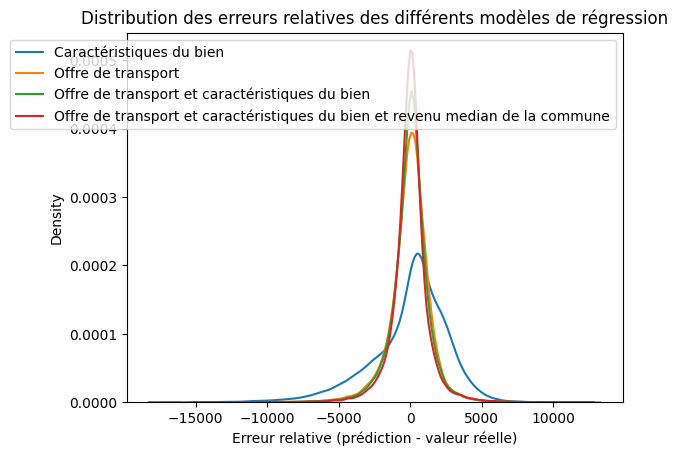

In [54]:
# affichage la distribution des erreurs absolues avec seaborn
import seaborn as sns
ax = sns.kdeplot(gdf["relative_error_prix_on_logement"], fill=False, label="Caractéristiques du bien")
sns.kdeplot(gdf["relative_error_prix_on_transport"], fill=False, label="Offre de transport", ax=ax)
sns.kdeplot(gdf["relative_error_prix_on_logement_transport"], fill=False, label="Offre de transport et caractéristiques du bien", ax=ax)
sns.kdeplot(gdf["relative_error_prix_on_logement_transport_revenu"], fill=False, label="Offre de transport et caractéristiques du bien et revenu median de la commune", ax=ax)
ax.set_xlabel("Erreur relative (prédiction - valeur réelle)")
ax.set_title("Distribution des erreurs relatives des différents modèles de régression")
ax.legend()

## Analyse de la qualité prédictive des modèles de prix immobiliers

**1. Résultats des modèles**


**R2**

Les performances de quatre modèles ont été évaluées en utilisant le coefficient de détermination (R²) et différentes mesures d'erreur (MSE, RMSE, MAE, RMSPE).

- Le modèle basé uniquement sur les caractéristiques du bien explique seulement 25 % de la variance des prix, ce qui est faible.  
- L’ajout de l’offre de transport améliore significativement la performance (R² test ~0.69), ce qui montre que l’accessibilité est un facteur clé des prix immobiliers.  
- Le modèle complet, intégrant caractéristiques du bien, offre de transport et revenu médian, atteint un R² test de 0.748, indiquant qu’il explique environ 75 % de la variance.  
- La différence modérée entre R² train et R² test indique que le modèle généralise correctement sans surapprentissage important.

**Mesures d’erreur**

- Les erreurs diminuent de manière significative à mesure que l’on enrichit le modèle, comme l’illustre la baisse continue du MAE. Celui-ci passe de 2 003 pour le modèle basé uniquement sur les caractéristiques du bien à 849 pour le modèle complet. Cela signifie qu’en moyenne, l’erreur absolue de prédiction est divisée par plus de deux lorsque l’on intègre l’offre de transport et le revenu médian de la commune.
- Pour le modèle le plus complet, un MAE de 849 indique qu’un bien dont le prix réel est par exemple de 5 000 (dans l’unité de mesure utilisée) est prédit en moyenne avec une erreur d’environ ±850. De même, pour un bien valorisé à 10 000, l’erreur moyenne reste du même ordre de grandeur absolu, ce qui peut représenter une incertitude significative en valeur relative.
- Bien que le modèle complet réduise l’erreur relative (RMSPE) à environ 36 %, ce niveau de précision est adapté à des analyses de tendances globales ou à des comparaisons entre zones géographiques, mais reste insuffisant pour des prédictions précises à l’échelle d’un bien immobilier individuel, notamment dans un contexte d’aide à la décision pour la fixation d’un prix de vente.

**2. Suggestions d’amélioration**

**Ajouter des variables supplémentaires :** proximité des écoles, commerces, espaces verts, âge et qualité du bien, dynamique du marché local.  

## Analyses géographiques :

Lorsqu'on n'utilise que les caractéristiques du logment (Surface, taille du terrain, nombre de pièces) le modèle sous-estime le prix des logements du centre de paris et sur-estime ceux des banlieux.

In [55]:
# ,{
#         "short_name":"code_postal_on_logement_transport",
#         "long_name":"Prediction code postal avec caractéristiques du bien et de transport",
#         "cat":categorical_cols,
#         "num":numeric_cols + numeric_cols_transport,
#         "target":"Code_postal",
#         "type":"regression",
#     },{
#         "short_name":"prix_on_code_postal",
#         "long_name":"Prediction prix au m² avec code postal",
#         "cat":["Code_postal"],
#         "num":[],
#         "target":"Valeur foncière au mètre carré",
#         "type":"regression",
#     },{
#         "short_name":"prix_on_code_postal_logement",
#         "long_name":"Prediction prix au m² avec code postal et caractéristiques du bien",
#         "cat":["Code_postal"] + categorical_cols,
#         "num":numeric_cols,
#         "target":"Valeur foncière au mètre carré",
#         "type":"regression",
#     }

In [56]:
from script.leaflet_tools import creation_heatmap, display_heatmap
import numpy as np
from branca.colormap import LinearColormap

def heatmap_relative_error(gdf, target_col):
    grid = creation_heatmap(
        gdf,
        cell_size=1000,
        target_value_col=target_col,
        min_points_per_cell=5
    )

    max_abs = np.max(np.abs(grid["moyenne"]))
    vmin, vmax = -max_abs, max_abs

    cmap = LinearColormap(
                colors= ["darkblue", "blue", "#d9d9d9", "red", "darkred"],
                vmin=vmin,
                vmax=vmax,
                caption="Erreur relative moyenne"
            )

    m = display_heatmap(
        grid,
        target_value_col="moyenne",
        cmap=cmap,
        default_cmap_caption="",
        legend=["Erreur relative", "Nombre de points"]
    )

    print("Heatmap de l'erreur relative moyenne, rouge = sur-estimation, bleu = sous-estimation")
    return m


from pathlib import Path

assets = Path("assets/maps")
assets.mkdir(parents=True, exist_ok=True)

heatmap_relative_error(gdf, target_col="relative_error_prix_on_logement").save(assets / "ml1.html")

Heatmap de l'erreur relative moyenne, rouge = sur-estimation, bleu = sous-estimation


[![Interactive map](/assets/maps/ml1.png)](/assets/maps/ml1.html)


Lorsqu'on ajoute l'offre de transport (avec ou sans les caractéristiques du logement) le modèle sous-estime le prix des logements à l'Ouest de Paris et surestime ceux à l'est. 

On remarque en particulier la Seine-Saint-Denis qui est un département bien desservi, mais peu cher. Pour faire de meilleures predictions, il est donc nécessaire d'ajouter des données supplémentaires expliquant ce genre de phénomènes.

In [57]:
heatmap_relative_error(gdf, target_col="relative_error_prix_on_transport").save(assets / "ml2.html")

Heatmap de l'erreur relative moyenne, rouge = sur-estimation, bleu = sous-estimation


In [58]:
heatmap_relative_error(gdf, target_col="relative_error_prix_on_logement_transport").save(assets / "ml3.html")

Heatmap de l'erreur relative moyenne, rouge = sur-estimation, bleu = sous-estimation


In [59]:
heatmap_relative_error(gdf, target_col="relative_error_prix_on_logement_transport_revenu").save(assets / "ml4.html")

Heatmap de l'erreur relative moyenne, rouge = sur-estimation, bleu = sous-estimation


L’ajout du revenu médian par commune comme variable explicative permet de mieux capturer les différences socio-économiques entre les zones et améliore les prévisions. En conséquence, la tendance à surestimer systématiquement les prix dans l’est ou à les sous-estimer dans l’ouest, observée avec les modèles précédents, disparaît. Les prédictions deviennent ainsi plus équilibrées et moins biaisées géographiquement, reflétant mieux la réalité du marché immobilier au-delà d’un simple effet Est-Ouest.

## Conclusion

Le modèle le plus complet permet d’expliquer 75 % de la variance des prix immobiliers et réduit l’erreur relative à 36 %. De plus, il permets d'éviter les biais géographique. Il est donc utilisable pour des analyses macro ou des tendances, mais reste insuffisant pour prédire précisément le prix d’un bien individuel. L’ajout de nouvelles variables et l’utilisation de modèles plus flexibles pourraient encore améliorer la précision.


# Économétrie 

## Préambule

Dans un second temps, l’objectif serait d’adopter une approche économétrique afin de quantifier l’impact des infrastructures de transport sur les prix immobiliers. Une telle analyse soulève toutefois des difficultés méthodologiques majeures. En particulier, la relation entre accessibilité aux transports et prix du logement est sujette à des problèmes de **causalité inverse** : les infrastructures de transport ne sont pas implantées aléatoirement, mais tendent à être développées dans des zones déjà attractives ou en anticipation d’une hausse de la demande immobilière.
Par ailleurs, un **biais d’omission de variables** est susceptible d’affecter les estimations. Des facteurs non observés, tels que les politiques locales d’aménagement, la qualité des services publics ou les dynamiques économiques locales, peuvent simultanément influencer la localisation des transports et le niveau des prix immobiliers. Ces différents mécanismes conduisent à une **endogénéité des variables de transport**, rendant les estimations issues de modèles standards biaisées et **difficilement interprétables sur le plan causal**.
Pour identifier un effet causal crédible, il serait nécessaire de recourir à des **méthodes quasi-expérimentales**. Parmi celles-ci, l’utilisation de variables instrumentales pourrait être envisagée, par exemple en exploitant la présence d’anciennes lignes ferroviaires comme instrument de l’accessibilité actuelle aux transports. Une autre approche consisterait à mettre en œuvre une méthode de différences-en-différences, en comparant l’évolution des prix immobiliers dans les zones affectées par l’ouverture de nouvelles lignes de transport à celle de zones similaires non concernées.

Faute de données suffisantes et en raison de contraintes de temps, nous avons mené une analyse qui ne peut prétendre à l’identification d’un effet causal. Elle demeure néanmoins pertinente en ce qu’elle complète l’analyse précédente en apportant des éléments descriptifs et exploratoires sur la relation entre accessibilité aux transports et prix immobiliers. Cette approche permet de mettre en évidence des corrélations structurantes et d’orienter de futures recherches, qui pourraient s’appuyer sur des données plus riches et des méthodes économétriques adaptées afin d’identifier rigoureusement les mécanismes causaux sous-jacents. 

## Méthodologie 

### 1. Analyse exploratoire des corrélations

Dans un premier temps, une analyse exploratoire des données est réalisée à l’aide de matrices de corrélation portant sur l’ensemble des variables numériques. Cette étape permet d’identifier la présence de fortes corrélations, en particulier entre les variables décrivant l’accessibilité et l’offre de transport (distances aux infrastructures, nombre de lignes et de stations, volumes de passages journaliers). Ces corrélations élevées indiquent un risque important de multicolinéarité si ces variables sont introduites simultanément dans un modèle de régression linéaire classique.

### 2. Réduction de dimension par Analyse en Composantes Principales (ACP)

Afin de traiter la multicolinéarité et de synthétiser l’information contenue dans les variables de transport, une Analyse en Composantes Principales (ACP) est appliquée exclusivement à ces variables.  
Avant l’ACP, l’ensemble des variables de transport est standardisé afin de garantir une contribution équivalente de chaque variable à la construction des composantes.

Les cinq premières composantes principales sont conservées. Ce choix repose sur :
- le critère de Kaiser (valeurs propres supérieures à 1),
- l’analyse du scree plot,
- et la part de variance expliquée cumulée, jugée suffisante pour résumer l’information pertinente liée aux transports.


### 3. Sélection des variables par Lasso

Dans un second temps, une procédure de sélection de variables est menée à l’aide d’une régression Lasso avec validation croisée (LassoCV). Cette méthode est particulièrement adaptée dans un contexte où le nombre de variables explicatives est élevé et potentiellement corrélé, car elle pénalise les coefficients et peut en annuler certains.

Les variables explicatives sont standardisées, condition indispensable au bon fonctionnement du Lasso. La variable dépendante est la valeur foncière au mètre carré, exprimée en logarithme afin de :
- réduire l’asymétrie de la distribution des prix,
- limiter l’influence des valeurs extrêmes,
- permettre une interprétation en termes de semi-élasticité.

Le Lasso permet ainsi d’identifier un sous-ensemble de variables pertinentes, incluant à la fois des caractéristiques intrinsèques des biens, des variables socio-économiques et les composantes principales liées aux transports.

### 4. Estimation du modèle OLS log-niveau

À partir des variables sélectionnées, un modèle de régression linéaire est estimé par la méthode des moindres carrés ordinaires (OLS). Le modèle retenu est de type **log-niveau**, où le logarithme du prix au mètre carré est expliqué par des variables exprimées en niveau.

### 5. Limites de l’approche

Bien que cette méthodologie permette de structurer l’information, de limiter la multicolinéarité et d’identifier des relations statistiques robustes, elle ne permet pas d’identifier des effets causaux. Les variables liées aux transports restent potentiellement endogènes en raison de phénomènes de causalité inverse et de variables omises. En l’absence de données temporelles détaillées ou de chocs exogènes exploitables, l’analyse doit être interprétée comme descriptive et corrélationnelle.


In [60]:
import geopandas as gpd
import pandas as pd
import os
if os.getcwd().endswith("notebooks"):
    os.chdir('..')

# Load a sample geospatial dataset
gdf = gpd.read_file("cache/results/logements_transport_final.geojson")

# Display the first few rows of the GeoDataFrame
# ensure every column is shown
pd.set_option('display.max_columns', None)
print(gdf.keys())

gdf = gdf.drop(columns=["adresse", "Commune", "Code commune",
                        "nearest_bus_stop_id", "nearest_metro_stop_id",
                        "nearest_train_stop_id", "nearest_tramway_stop_id"])
save_gdf = gdf.copy()

Index(['adresse', 'Code_postal', 'dist_centre_paris_m', 'Department',
       'Type local', 'Commune', 'Surface reelle bati', 'Surface terrain',
       'Nombre pieces principales', 'Code commune',
       'Valeur foncière au mètre carré', 'nearest_bus_stop_id',
       'nearest_bus_dist_m', 'nearest_metro_stop_id', 'nearest_metro_dist_m',
       'nearest_tramway_stop_id', 'nearest_tramway_dist_m',
       'nearest_train_stop_id', 'nearest_train_dist_m',
       'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km',
       'nb_routes_bus_1km', 'nb_stations_tramway_1km', 'nb_stations_metro_1km',
       'nb_stations_train_1km', 'nb_stations_bus_1km',
       'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
       'passage_journalier_train_1km', 'passage_journalier_bus_1km', 'RDB_M',
       'geometry'],
      dtype='object')


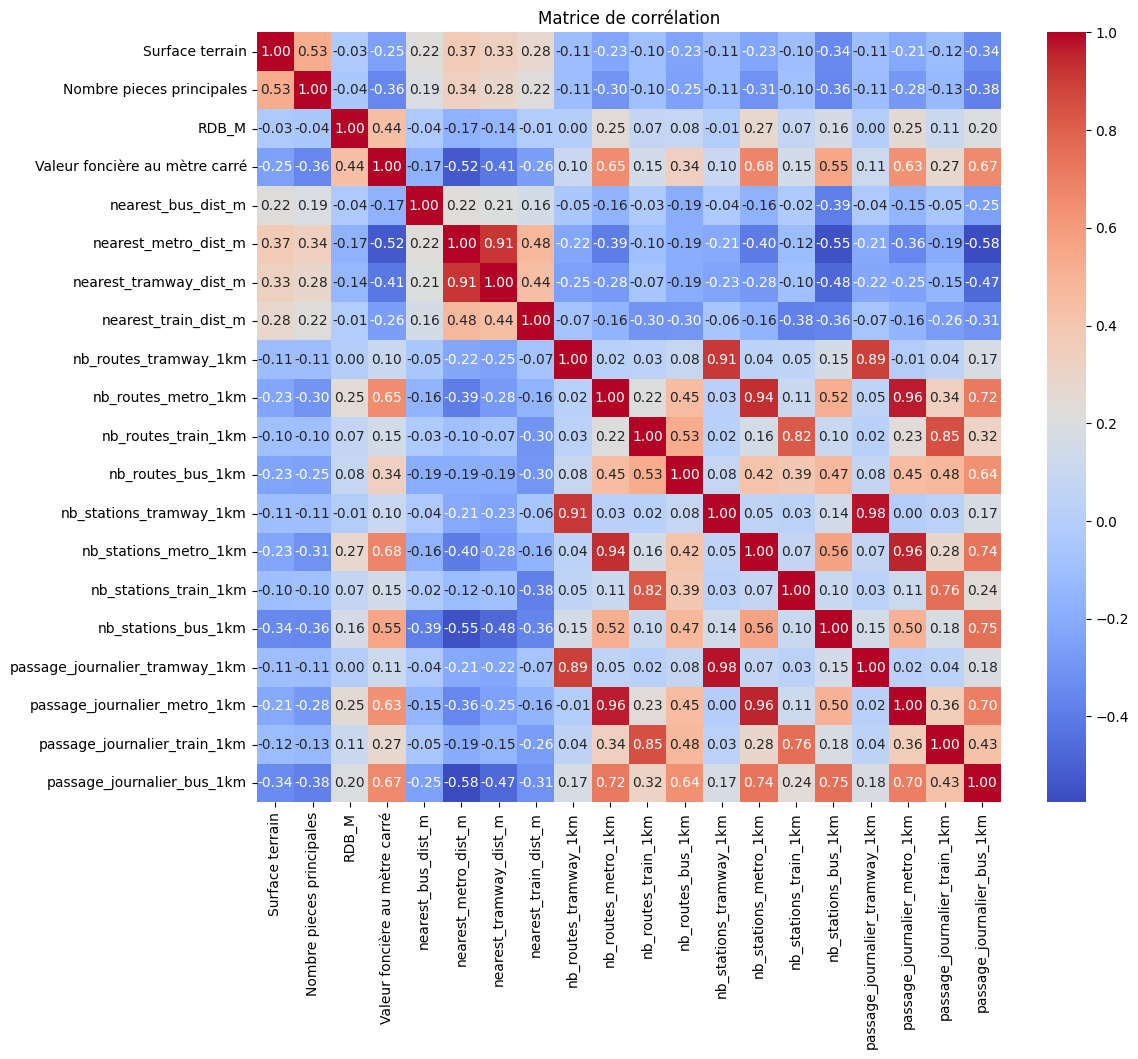

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns 

numerical_vars = [
    'Surface terrain', 'Nombre pieces principales','RDB_M',
    'Valeur foncière au mètre carré', 
    'nearest_bus_dist_m', 'nearest_metro_dist_m', 'nearest_tramway_dist_m', 'nearest_train_dist_m',
    'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km', 'nb_routes_bus_1km',
    'nb_stations_tramway_1km', 'nb_stations_metro_1km', 'nb_stations_train_1km', 'nb_stations_bus_1km',
    'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
    'passage_journalier_train_1km', 'passage_journalier_bus_1km'
]

gdf_num = gdf[numerical_vars]

corr_matrix = gdf_num.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

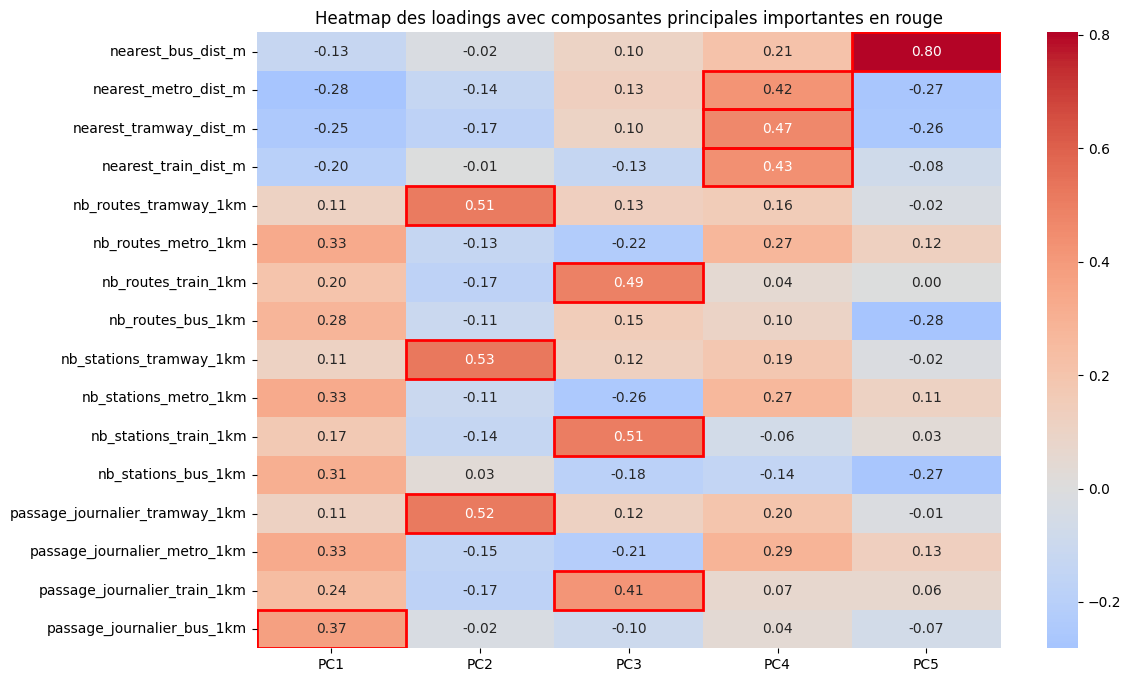

In [62]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Sélection des variables de transport ---
transport_vars = [
    'nearest_bus_dist_m', 'nearest_metro_dist_m', 'nearest_tramway_dist_m', 'nearest_train_dist_m',
    'nb_routes_tramway_1km', 'nb_routes_metro_1km', 'nb_routes_train_1km', 'nb_routes_bus_1km',
    'nb_stations_tramway_1km', 'nb_stations_metro_1km', 'nb_stations_train_1km', 'nb_stations_bus_1km',
    'passage_journalier_tramway_1km', 'passage_journalier_metro_1km',
    'passage_journalier_train_1km', 'passage_journalier_bus_1km'
]

X = gdf[transport_vars]

# --- Standardisation ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- ACP ---
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# --- DataFrame des loadings ---
loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f'PC{i+1}' for i in range(5)], 
                        index=transport_vars)

# --- Heatmap des loadings ---
plt.figure(figsize=(12,8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt=".2f")

# Ajouter un rectangle rouge autour des valeurs "importantes"
threshold = 0.35
for i, col in enumerate(loadings.columns):
    for j, val in enumerate(loadings[col]):
        if abs(val) > threshold:
            plt.gca().add_patch(plt.Rectangle((i, j), 1, 1, fill=False, edgecolor='red', lw=2))

plt.title("Heatmap des loadings avec composantes principales importantes en rouge")
plt.show()

# Interprétation des composantes principales (ACP)

L’Analyse en Composantes Principales (ACP) permet de résumer l’information contenue dans un grand nombre de variables de transport fortement corrélées en un nombre réduit de facteurs synthétiques, appelés composantes principales. Chaque composante est une combinaison linéaire des variables initiales, pondérées par des coefficients appelés loadings. Ces loadings indiquent la contribution relative de chaque variable à la composante considérée.

**PC1 – Intensité globale de l’offre de transport**
La première composante principale (PC1) est caractérisée par des coefficients positifs relativement élevés pour :
le nombre de lignes et de stations (bus, métro),
les volumes de passages journaliers, en particulier pour le bus.
Cette composante capture donc une intensité globale de l’offre de transport et de la fréquentation dans un rayon proche. Des valeurs élevées de PC1 correspondent à des zones bien desservies, avec une forte densité de réseaux et une activité de transport importante.

**PC2 – Présence du tramway**
La deuxième composante (PC2) est dominée par :
le nombre de lignes et de stations de tramway,
les passages journaliers du tramway.
Elle reflète une structuration locale autour du réseau de tramway, souvent associée à des zones urbaines denses ou récemment aménagées. Cette composante distingue donc les territoires où le tramway joue un rôle central dans l’accessibilité.

**PC3 – Accessibilité ferroviaire (train)**
La troisième composante (PC3) est principalement portée par :
le nombre de lignes et de stations de train,
les passages journaliers ferroviaires.
PC3 peut être interprétée comme une mesure de l’accessibilité aux réseaux ferroviaires lourds, souvent liée à des connexions interurbaines ou régionales.

**PC4 – Proximité aux infrastructures de transport**
La quatrième composante (PC4) est dominée par des coefficients positifs sur les distances aux stations (métro, tramway, train). Elle mesure essentiellement la proximité physique aux infrastructures de transport : des valeurs élevées correspondent à des biens situés plus loin des stations, tandis que des valeurs faibles traduisent une meilleure accessibilité spatiale.

**PC5 – Éloignement spécifique du réseau de bus**
Enfin, la cinquième composante (PC5) est très fortement corrélée à la distance au bus le plus proche. Elle capte donc une dimension spécifique d’isolement vis-à-vis du réseau de bus, indépendante des autres modes de transport.